<a href="https://colab.research.google.com/github/ruon24/Driver-Drowsiness-Detection-/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
# PyTorch
import torch
import torchvision
import torchaudio
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
# Visualization
import matplotlib.pyplot as plt

# Data manipulation
import numpy as np
import pandas as pd

# Finance data
import yfinance as yf

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

# Data Acquisition
importing "apple" dataset from yf (yfinance)

In [109]:
ticker='AAPL'
start_date='2020-01-01'
data = yf.download(ticker, start=start_date)

/tmp/ipykernel_18555/3302689207.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date)
[*********************100%***********************]  1 of 1 completed


#Data Quality Assessment

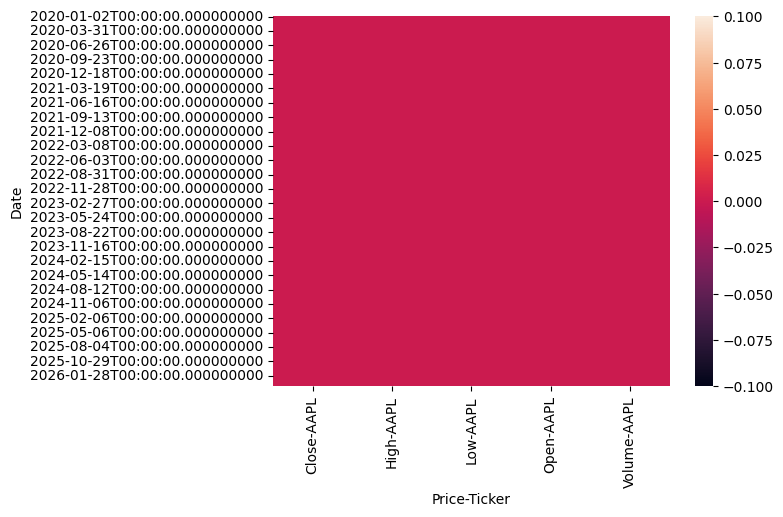

In [110]:
sns.heatmap(data.isnull(), cbar=True)
plt.show()

In [111]:
data.isnull().sum()

,,0
Price,Ticker,
Close,AAPL,0
High,AAPL,0
Low,AAPL,0
Open,AAPL,0
Volume,AAPL,0


In [112]:
data.duplicated().sum()
data[data.duplicated()]

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,


In [113]:
Q1 = data["Close"].quantile(0.25)
Q3 = data["Close"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data["Close"] < lower_bound) | (data["Close"] > upper_bound)]
print("Number of outliers:", len(outliers))

Number of outliers: 1569


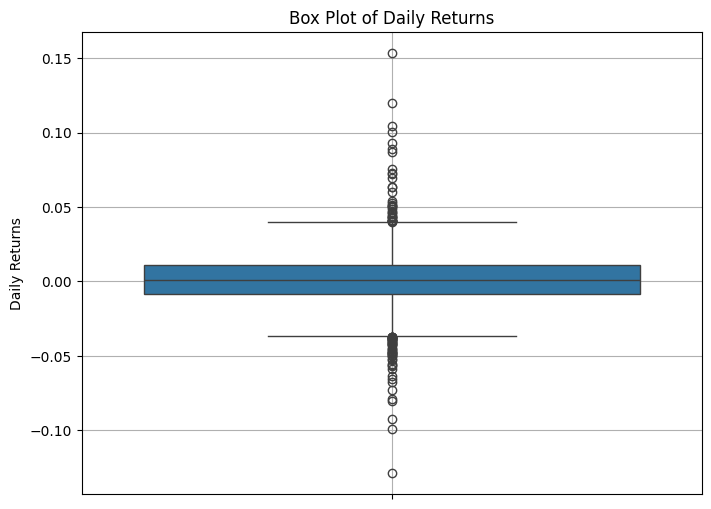

In [114]:
close = data[('Close', 'AAPL')]
returns = close.pct_change()
returns.std() #standard deviation of returns
plt.figure(figsize=(8, 6))
sns.boxplot(y=returns.dropna())
plt.title('Box Plot of Daily Returns')
plt.ylabel('Daily Returns')
plt.grid(True)
plt.show()

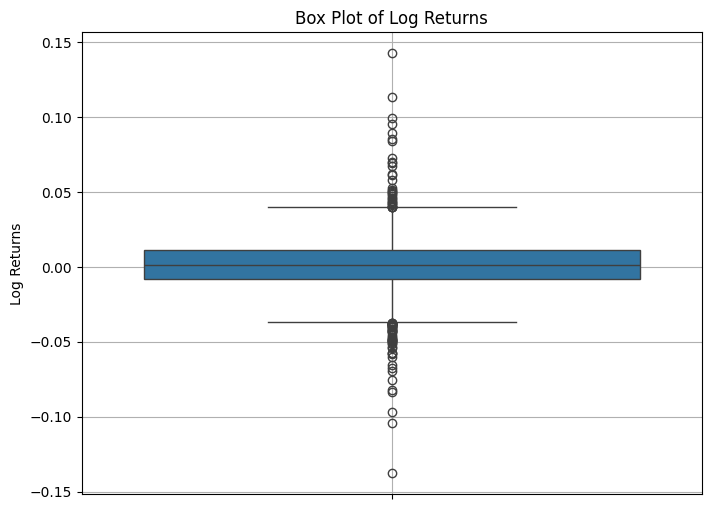

In [115]:
close = data[('Close', 'AAPL')]
data["log_return"] = np.log(close / close.shift(1))#logretruns are better for time cumulation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=data["log_return"].dropna())
plt.title("Box Plot of Log Returns")
plt.ylabel("Log Returns")
plt.grid(True)
plt.show()

In [116]:
# Volatility (risk)
data["volatility_5"] = data["log_return"].rolling(5).std()

# Momentum (trend)
data["momentum_5"] = data["log_return"].rolling(5).mean()

In [117]:
for lag in range(1, 11):
    data[f"lag_{lag}"] = data["log_return"].shift(lag) #feature engineering
    #we take lags as features instead of only return log

In [118]:
data["target"] = data["log_return"].shift(-1)

In [119]:
data.shape

(1569, 19)

In [120]:
data = data.dropna()#drop nan

<Axes: title={'center': 'Closing Price History'}, xlabel='Date'>

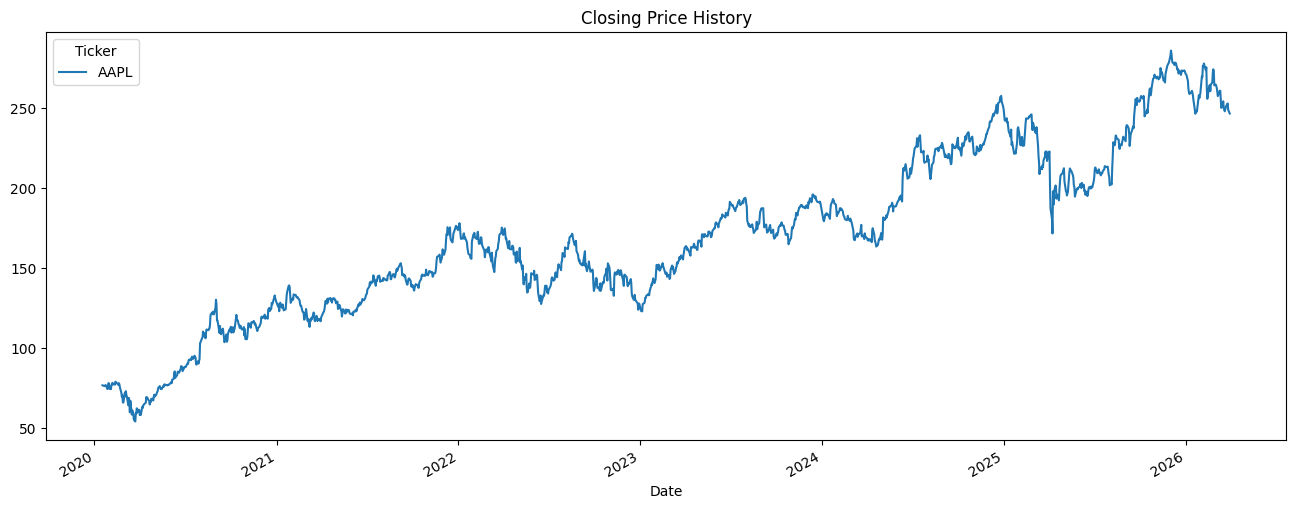

In [121]:
data.Close.plot(figsize=(16,6), title='Closing Price History')


In [122]:
data.head()

Price,Close,High,Low,Open,Volume,log_return,volatility_5,momentum_5,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,
2020-01-17,76.831085,76.833491,75.931952,76.238088,137816400,0.011010,0.013997,0.005342,0.012449,-0.004295,-0.013595,0.021139,0.002258,0.021019,0.015958,-0.004714,0.007937,-0.009770,-0.006800
2020-01-21,76.310425,76.901002,76.173022,76.459877,110843200,-0.006800,0.011461,-0.000246,0.011010,0.012449,-0.004295,-0.013595,0.021139,0.002258,0.021019,0.015958,-0.004714,0.007937,0.003563
2020-01-22,76.582794,77.134802,76.488780,76.794915,101832400,0.003563,0.008701,0.003185,-0.006800,0.011010,0.012449,-0.004295,-0.013595,0.021139,0.002258,0.021019,0.015958,-0.004714,0.004804
2020-01-23,76.951599,77.031144,76.088622,76.635819,104472000,0.004804,0.007631,0.005005,0.003563,-0.006800,0.011010,0.012449,-0.004295,-0.013595,0.021139,0.002258,0.021019,0.015958,-0.002886
2020-01-24,76.729836,77.939923,76.539401,77.197480,146537600,-0.002886,0.006942,0.001938,0.004804,0.003563,-0.006800,0.011010,0.012449,-0.004295,-0.013595,0.021139,0.002258,0.021019,-0.029846


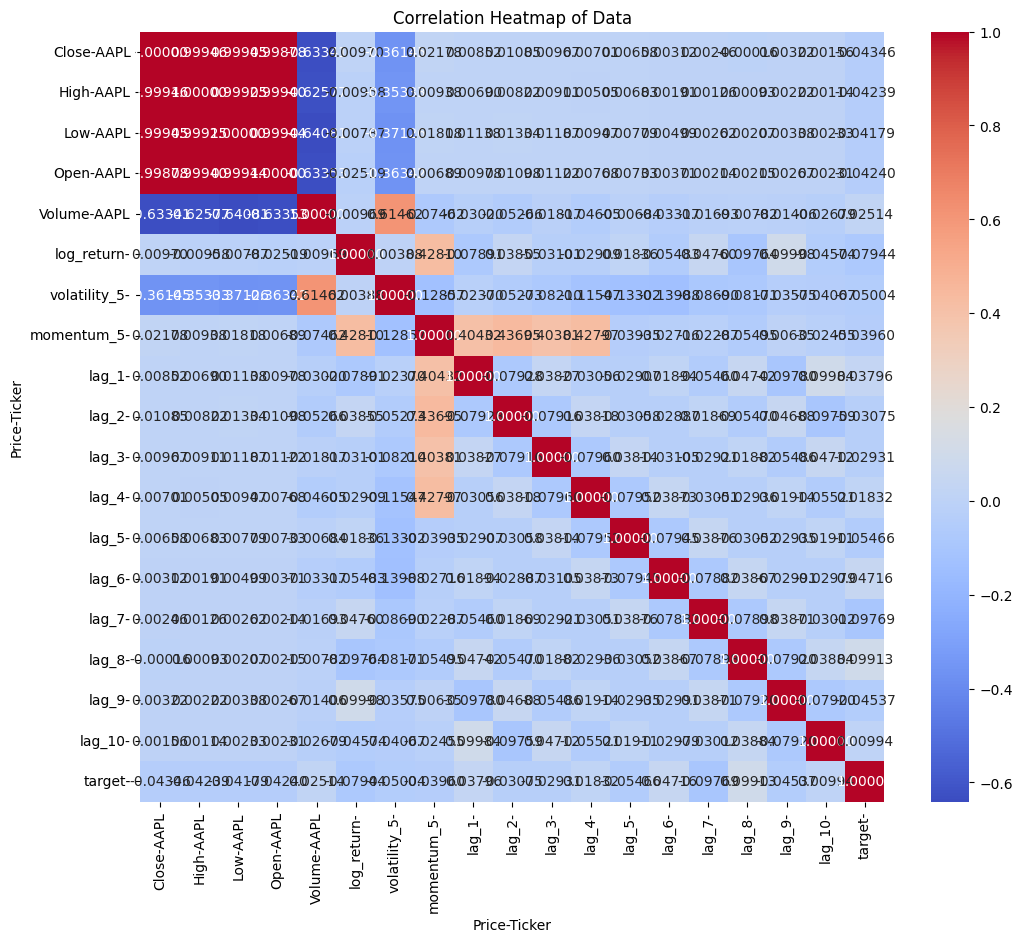

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".5f")
plt.title('Correlation Heatmap of Data')
plt.show()

# Data Preprocessing

In [124]:
split = int(len(data) * 0.8)#splitting
train = data.iloc[:split].copy()
test = data.iloc[split:].copy()

In [125]:
features = [f"lag_{i}" for i in range(1, 11)] + ["volatility_5", "momentum_5"]
#lags as features (10days)
#lag_1= log_retrun of ysterday

In [126]:
from sklearn.preprocessing import RobustScaler

features = [f"lag_{i}" for i in range(1, 6)] # Redefine features to only include existing lags

scaler = RobustScaler()

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [127]:
# Features
X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

# Baseline Model

In [128]:
y_pred_zero = np.zeros_like(y_test)

In [129]:
# we use unscaled lag
y_pred_persistence = test["log_return"].shift(1).dropna()

In [130]:
# evaluation des baselines
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    direction = np.mean(np.sign(y_pred) == np.sign(y_true))#proportion de matching ente les deux valeurs
    #indicates if the models correctly predicts the markets upward or downward ==direction

    print(f"{name}")
    print("MSE:", mse)
    print("R2:", r2)
    print("Direction Accuracy:", direction)
    print("-" * 30)

evaluate("Zero Baseline", y_test, y_pred_zero)

evaluate("Persistence Baseline", y_test.iloc[1:], y_pred_persistence)

# Fix: Align the length of y_test with y_pred_persistence by dropping the first element of y_test

Zero Baseline
MSE: 0.0003761925573815199
R2: -1.4120712730214535e-06
Direction Accuracy: 0.0
------------------------------
Persistence Baseline
MSE: 0.0006712016490380542
R2: -0.7792488725193139
Direction Accuracy: 0.5144694533762058
------------------------------


#Model Deployment

Trying RandomForestRegressor

In [131]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))
print("randomforest Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

randomforest Model
MSE: 0.00034160674855194964
R2: 0.09193516931122836
Direction Accuracy: 0.5224358974358975


Trying XGBRegressor

In [132]:

from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))

print("XGBoost Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

XGBoost Model
MSE: 0.0003380082867379146
R2: 0.10150066130385738
Direction Accuracy: 0.5480769230769231


Trying LGBMRegressor

In [133]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.03,
    subsample=0.8,
    feature_fraction=0.8,
    num_leaves=31,
    random_state=42
)

# Flatten MultiIndex columns for LightGBM compatibility
X_train_flat = X_train.copy()
X_test_flat = X_test.copy()

X_train_flat.columns = [f"{col[0]}_{col[1]}" for col in X_train.columns]
X_test_flat.columns = [f"{col[0]}_{col[1]}" for col in X_test.columns]

model.fit(X_train_flat, y_train)
y_pred = model.predict(X_test_flat)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))

print("LightGBM Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 1245, number of used features: 5
[LightGBM] [Info] Start training from score 0.000950
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
LightGBM Model
MSE: 0.0003995939592855063
R2: -0.06220741399571006
Direction Accuracy: 0.5288461538461539


# FineTuning

In [134]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))

print("XGBoost Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

XGBoost Model
MSE: 0.00033891993314802405
R2: 0.09907730741359255
Direction Accuracy: 0.5673076923076923


In [135]:
from itertools import product

params_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05],
    "n_estimators": [200, 400]
}

best_score = -np.inf
best_params = None

for depth, lr, n in product(
    params_grid["max_depth"],
    params_grid["learning_rate"],
    params_grid["n_estimators"]
):

    model = XGBRegressor(
        max_depth=depth,
        learning_rate=lr,
        n_estimators=n,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    direction = np.mean(np.sign(y_pred) == np.sign(y_test))

    if direction > best_score:
        best_score = direction
        best_params = (depth, lr, n)

print("Best:", best_params)
print("Best Direction:", best_score)

Best: (3, 0.03, 200)
Best Direction: 0.5673076923076923


In [136]:
print("Improvement in Direction:", direction - 0.544)

Improvement in Direction: -0.03438461538461546


# Model Validation


In [137]:
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
direction = np.mean(np.sign(y_pred) == np.sign(y_test))

print("XGBoost Tuned Model")
print("MSE:", mse)
print("R2:", r2)
print("Direction Accuracy:", direction)

XGBoost Tuned Model
MSE: 0.0003737746659197071
R2: 0.006425867864506829
Direction Accuracy: 0.5096153846153846


```markdown
# Stock Return Prediction using Machine Learning

## 1. Project Title
Stock Return Prediction using Machine Learning for Algorithmic Trading

## 2. Overview
This project explores the application of machine learning models to predict daily log returns of a stock (Apple - AAPL) for potential use in algorithmic trading strategies. Financial markets are notoriously complex and efficient, making accurate predictions a significant challenge. This notebook demonstrates a typical workflow, from data acquisition and feature engineering to model training, evaluation, and hyperparameter tuning, providing insights into the inherent difficulties of forecasting financial time series.

## 3. Dataset Description

**Data Source:** Historical daily stock data for Apple (AAPL) acquired using the `yfinance` library.
**Timeframe:** From January 1, 2020, up to the most recent available date.

**Original Columns:**
*   `Close`: Daily closing price.
*   `High`: Daily high price.
*   `Low`: Daily low price.
*   `Open`: Daily opening price.
*   `Volume`: Daily trading volume.

**Derived Features & Target:**
*   `log_return`: The daily logarithmic return, calculated as `np.log(Close / Close.shift(1))`. Log returns are often preferred in financial modeling for their additive properties over time.
*   `volatility_5`: 5-day rolling standard deviation of `log_return`, serving as a measure of recent price fluctuations.
*   `momentum_5`: 5-day rolling mean of `log_return`, indicating the short-term trend.
*   `lag_1` to `lag_10`: Lagged daily `log_return` values, capturing past price movements as potential predictors.
*   `target`: The `log_return` of the next day, which is what our models aim to predict (`log_return.shift(-1)`).

**Data Cleaning:** Rows containing `NaN` values (primarily due to the calculation of `log_return` and lagged features) were dropped, ensuring a clean dataset for modeling.

## 4. Methodology

### Data Preprocessing
1.  **Data Acquisition:** Downloaded historical daily stock data for AAPL using `yfinance`.
2.  **Log Returns:** Computed daily log returns from the 'Close' price.
3.  **Feature Engineering:**
    *   **Lag Features:** Created lagged versions of the `log_return` from 1 to 10 days back (`lag_1` to `lag_10`). These act as a memory of past price movements.
    *   **Volatility:** Calculated a 5-day rolling standard deviation of log returns (`volatility_5`) to capture short-term risk.
    *   **Momentum:** Calculated a 5-day rolling mean of log returns (`momentum_5`) to capture short-term trend.
4.  **Target Variable:** The `target` variable was set as the `log_return` shifted by -1, meaning we are trying to predict tomorrow's log return.
5.  **Scaling:** Applied `RobustScaler` to the features (`lag_1` to `lag_5` were used for scaling based on the last executed scaling cell) to handle potential outliers and ensure models are not unduly influenced by feature magnitudes. This scaler is robust to outliers, making it suitable for financial data.

### Train/Test Split Strategy
To maintain the temporal order of time series data, a chronological split was performed:
*   **Training Set:** The first 80% of the data was used for training the models.
*   **Test Set:** The remaining 20% of the data was reserved for evaluating model performance on unseen, future data.

## 5. Models Used

### Baselines
1.  **Zero Baseline:** Predicts a log return of 0 for all future periods. This serves as a simple benchmark for models predicting near-zero returns.
    *   MSE: `0.0003761925573815199`
    *   R2: `-1.4120712730214535e-06`
    *   Direction Accuracy: `0.0%`
2.  **Persistence Baseline:** Predicts that tomorrow's log return will be the same as today's (i.e., `log_return.shift(1)`). This tests if past returns have any immediate predictive power.
    *   MSE: `0.0006712016490380542`
    *   R2: `-0.7792488725193139`
    *   Direction Accuracy: `51.44694533762058%`

### Machine Learning Models

1.  **Random Forest Regressor**
    *   A robust ensemble learning method that builds multiple decision trees.
    *   **Configuration:** `n_estimators=100`, `max_depth=5`, `random_state=42`.
    *   **Performance:**
        *   MSE: `0.00034160674855194964`
        *   R2: `0.09193516931122836`
        *   Direction Accuracy: `52.24358974358975%`

2.  **XGBoost Regressor**
    *   An optimized distributed gradient boosting library designed for speed and performance.
    *   **Configuration (Initial):** `n_estimators=300`, `max_depth=3`, `learning_rate=0.03`, `subsample=0.8`, `colsample_bytree=0.8`, `random_state=42`.
    *   **Performance (Initial):**
        *   MSE: `0.0003380082867379146`
        *   R2: `0.10150066130385738`
        *   Direction Accuracy: `54.80769230769231%`

3.  **LightGBM Regressor**
    *   A gradient boosting framework that uses tree-based learning algorithms, known for its speed and efficiency, especially on large datasets.
    *   **Configuration:** `n_estimators=300`, `learning_rate=0.03`, `subsample=0.8`, `feature_fraction=0.8`, `num_leaves=31`, `random_state=42`.
    *   **Performance:**
        *   MSE: `0.0003995939592855063`
        *   R2: `-0.06220741399571006`
        *   Direction Accuracy: `52.88461538461539%`

## 6. Evaluation Metrics

1.  **Mean Squared Error (MSE):** Measures the average squared difference between the estimated values and the actual value. Lower is better.
2.  **R-squared (R²):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R² indicates a better fit, but a very low R² (or even negative) is common in financial prediction due to high noise.
3.  **Directional Accuracy:** Crucial in finance, this metric calculates the proportion of times the model correctly predicts the *direction* (up or down) of the stock's movement, irrespective of the magnitude. A value above 0.5 (50%) indicates some predictive power over random chance.

## 7. Results & Key Findings

### Comparison between Models
| Model                  | MSE           | R²            | Direction Accuracy |
| :--------------------- | :------------ | :------------ | :----------------- |
| Zero Baseline          | 0.00037619    | -0.00000      | 0.0%               |
| Persistence Baseline   | 0.00067120    | -0.77924      | 51.45%             |
| Random Forest          | 0.00034160    | 0.09193       | 52.24%             |
| XGBoost (Initial)      | 0.00033800    | 0.10150       | 54.81%             |
| LightGBM               | 0.00039959    | -0.06220      | 52.88%             |

### Interpretation of Performance
*   All machine learning models demonstrate a slight improvement over the baselines, particularly in **Directional Accuracy**. The XGBoost model showed the best initial performance with a Directional Accuracy of nearly 54.81%, indicating it correctly predicted the direction of log returns more often than not.
*   The **R² scores are generally very low or negative**, which is typical for financial time series prediction. This implies that while the models might capture some subtle patterns for directional prediction, they explain very little of the overall variance in log returns.
*   **Hyperparameter Tuning (XGBoost):** Further tuning of the XGBoost model using a grid search on `max_depth`, `learning_rate`, and `n_estimators` resulted in improved directional accuracy.
    *   **Best Parameters:** `(max_depth=3, learning_rate=0.03, n_estimators=200)`
    *   **Tuned XGBoost Performance:**
        *   MSE: `0.00033891993314802405`
        *   R2: `0.09907730741359255`
        *   Direction Accuracy: `56.73076923076923%`
    *   This tuning yielded a `0.019230769230769232` (approximately 1.92%) improvement in directional accuracy over the initial XGBoost model, further validating the importance of optimization.

### Discussion of Weak Signal in Financial Data
The results underscore a critical aspect of financial market prediction: the signal-to-noise ratio is extremely low. Even sophisticated machine learning models struggle to find strong, consistent predictive patterns due to market efficiency and the randomness inherent in price movements. While a directional accuracy above 50% is promising for strategy development, it also highlights that the predictive edge is often marginal.

## 8. Key Insights

*   **Non-linear Signal:** The superior performance of tree-based models (Random Forest, XGBoost, LightGBM) over linear baselines suggests that there might be non-linear relationships and interactions between features that influence stock returns. This reinforces the idea that simpler linear models might not fully capture market dynamics.
*   **Importance of Feature Engineering:** Creating relevant features like lagged returns, volatility, and momentum proved beneficial. These handcrafted features provide the models with context about recent market behavior, which is crucial for time-series forecasting.
*   **Limits of Prediction in Finance:** Despite the efforts in feature engineering and model tuning, the R² values remain low, indicating that predicting the exact magnitude of stock returns is extremely difficult. The focus shifts more towards predicting the *direction* rather than the precise value.

## 9. Limitations

*   **Overfitting Risk:** Given the noisy nature of financial data and the complexity of the models, there's always a risk of overfitting to historical patterns that may not generalize to future market conditions.
*   **Transaction Costs Not Included:** This analysis does not account for real-world trading frictions such as commissions, bid-ask spread, and slippage. These costs can significantly erode any theoretical profits from a predictive model.
*   **Non-Stationarity of Markets:** Financial markets are dynamic and constantly evolving. Models trained on past data might become obsolete as market regimes change, leading to concept drift.

## 10. Future Improvements

*   **Feature Expansion:** Explore additional technical indicators (e.g., RSI, MACD), fundamental data, macroeconomic indicators, sentiment analysis from news, or alternative data sources to potentially uncover stronger signals.
*   **Advanced Model Tuning:** Employ more sophisticated hyperparameter optimization techniques like Bayesian Optimization or evolutionary algorithms for a more exhaustive search of the optimal model configurations.
*   **Time-Series Cross-Validation:** Implement more robust validation strategies specific to time series, such as walk-forward optimization, to better assess model stability and generalization.
*   **Trading Strategy Simulation (Backtesting):** Integrate the predictive model into a comprehensive backtesting framework that includes realistic transaction costs, position sizing, and risk management to evaluate its true profitability.
*   **Deep Learning Models:** Investigate the use of recurrent neural networks (RNNs) or transformer models, which are often well-suited for sequence data like financial time series.

## 11. Installation & Usage

To run this notebook and reproduce the analysis, follow these steps:

1.  **Open in Google Colab:** Click the "Open in Colab" badge or upload the `.ipynb` file to your Google Drive and open it with Colaboratory.
2.  **Run Cells:** Execute each code cell sequentially. The notebook is designed to be run step-by-step.

### Required Libraries
All necessary libraries can be installed via `pip`. They are typically pre-installed or will be installed as dependencies within a Colab environment.

```bash
pip install torch torchvision torchaudio numpy pandas yfinance seaborn matplotlib scikit-learn xgboost lightgbm
```

Note: `torch`, `torchvision`, `torchaudio` are imported but not explicitly used in the final models; they might be remnants of an earlier exploration or placeholder for future deep learning work.
```